# Modelos de Regresión y Clasificación — Dataset de Incendios

Este notebook entrena y evalúa cuatro modelos sobre el dataset `dataset_incendios_listo_modelos.csv`:

1. **Regresión Lineal Simple** (`frp_log ~ brightness`)
2. **Regresión Lineal Múltiple** (`frp_log ~ brightness + bright_t31 + scan + track + confidence_num`)
3. **Regresión Logística** (`daynight_num ~ brightness + bright_t31 + scan + track + frp`)
4. **KNN** (`daynight_num ~ brightness + bright_t31 + scan + track + frp`)


## 1. Librerías

Todas las librerías usadas en el notebook, importadas una sola vez.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    precision_recall_curve, classification_report
)


## 2. Carga del dataset

In [2]:
# Usamos la ruta interna de Google Colab donde ya está tu archivo
df = pd.read_csv('/content/dataset_incendios_listo_modelos.csv')

print("¡Éxito! El dataset se cargó correctamente.")
df.head(2)


/tmp/ipykernel_2230/1199568414.py:2: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/dataset_incendios_listo_modelos.csv')


¡Éxito! El dataset se cargó correctamente.


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_num,frp_log,daynight_num
0,-14.19033,-61.34149,303.75,0.43,0.38,01/01/2025,529,N20,VIIRS,n,2,282.14,1.56,N,50.0,0.940007,0
1,-14.19383,-61.34204,300.92,0.43,0.38,01/01/2025,529,N20,VIIRS,n,2,281.91,0.75,N,50.0,0.559616,0


## 3. Regresión Lineal Simple

`frp_log ~ brightness`

In [3]:
X_simple = df[['brightness']]
y = df['frp_log']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)

y_pred_s = modelo_simple.predict(X_test_s)

mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)
mask_s = y_test_s != 0
mape_s = mean_absolute_percentage_error(y_test_s[mask_s], y_pred_s[mask_s])

print("REGRESIÓN LINEAL SIMPLE (frp_log ~ brightness)")
print("-" * 55)
print(f"Coeficiente (pendiente): {modelo_simple.coef_[0]:.4f}")
print(f"Intercepto: {modelo_simple.intercept_:.4f}")
print(f"MAE  : {mae_s:.4f}")
print(f"MSE  : {mse_s:.4f}")
print(f"RMSE : {rmse_s:.4f}")
print(f"R2   : {r2_s:.4f}")
print(f"MAPE : {mape_s:.4f}")


REGRESIÓN LINEAL SIMPLE (frp_log ~ brightness)
-------------------------------------------------------
Coeficiente (pendiente): 0.0304
Intercepto: -7.9845
MAE  : 0.6098
MSE  : 0.6364
RMSE : 0.7977
R2   : 0.3308
MAPE : 0.3776


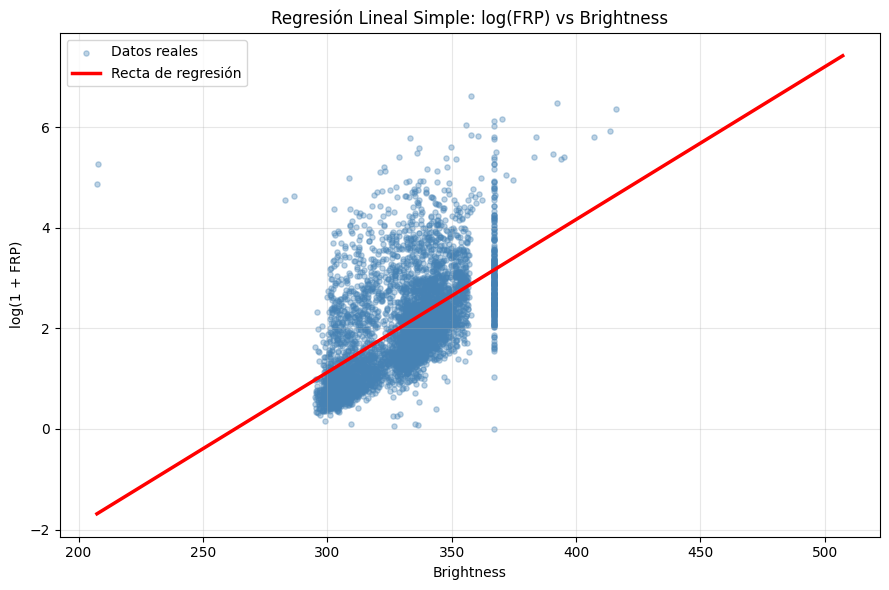

In [4]:
# Gráfico 1: Dispersión (muestra) + línea de regresión
muestra_s = X_test_s.sample(5000, random_state=42).index
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_test_s.loc[muestra_s], y_test_s.loc[muestra_s],
           color='steelblue', alpha=0.35, s=14, label='Datos reales')
X_linea = pd.DataFrame(
    np.linspace(X_simple.min().values[0], X_simple.max().values[0], 200),
    columns=['brightness']
)
ax.plot(X_linea, modelo_simple.predict(X_linea), color='red', linewidth=2.5, label='Recta de regresión')
ax.set_xlabel('Brightness')
ax.set_ylabel('log(1 + FRP)')
ax.set_title('Regresión Lineal Simple: log(FRP) vs Brightness')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


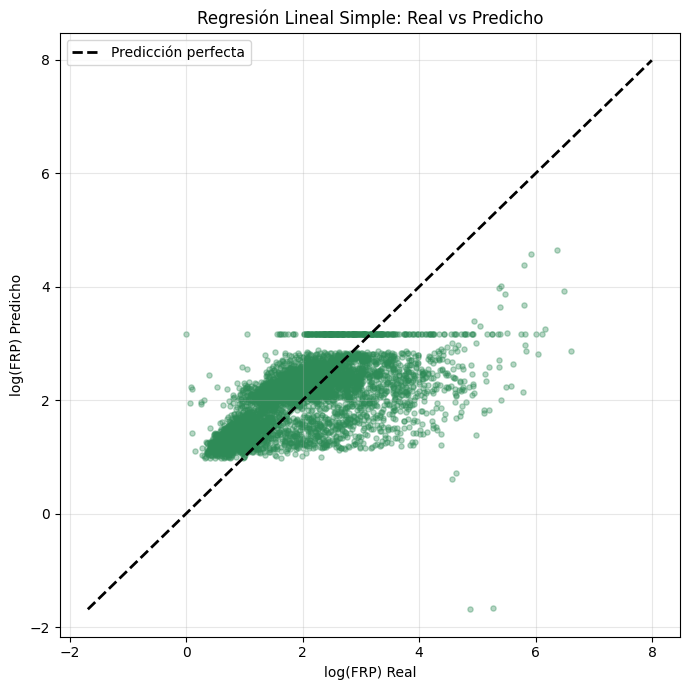

In [5]:
# Gráfico 2: Real vs Predicho (muestra)
muestra_idx = y_test_s.sample(5000, random_state=42).index
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_s.loc[muestra_idx], pd.Series(y_pred_s, index=y_test_s.index).loc[muestra_idx],
           color='seagreen', alpha=0.35, s=14)
lims = [min(y_test_s.min(), y_pred_s.min()), max(y_test_s.max(), y_pred_s.max())]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('log(FRP) Real')
ax.set_ylabel('log(FRP) Predicho')
ax.set_title('Regresión Lineal Simple: Real vs Predicho')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Regresión Lineal Múltiple

`frp_log ~ brightness + bright_t31 + scan + track + confidence_num`

In [6]:
predictoras = ['brightness', 'bright_t31', 'scan', 'track', 'confidence_num']
X_multiple = df[predictoras]
y = df['frp_log']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train_m)

y_pred_m = modelo_multiple.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)
mask_m = y_test_m != 0
mape_m = mean_absolute_percentage_error(y_test_m[mask_m], y_pred_m[mask_m])

print("REGRESIÓN LINEAL MÚLTIPLE (frp_log ~ brightness + bright_t31 + scan + track + confidence_num)")
print("-" * 85)
for var, coef in zip(predictoras, modelo_multiple.coef_):
    print(f"Coeficiente {var:15s}: {coef:.4f}")
print(f"Intercepto: {modelo_multiple.intercept_:.4f}")
print(f"MAE  : {mae_m:.4f}")
print(f"MSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f}")
print(f"R2   : {r2_m:.4f}")
print(f"MAPE : {mape_m:.4f}")


REGRESIÓN LINEAL MÚLTIPLE (frp_log ~ brightness + bright_t31 + scan + track + confidence_num)
-------------------------------------------------------------------------------------
Coeficiente brightness     : 0.0292
Coeficiente bright_t31     : 0.0197
Coeficiente scan           : 0.5721
Coeficiente track          : 1.0192
Coeficiente confidence_num : 0.0014
Intercepto: -14.3844
MAE  : 0.4273
MSE  : 0.3524
RMSE : 0.5936
R2   : 0.6294
MAPE : 0.2529


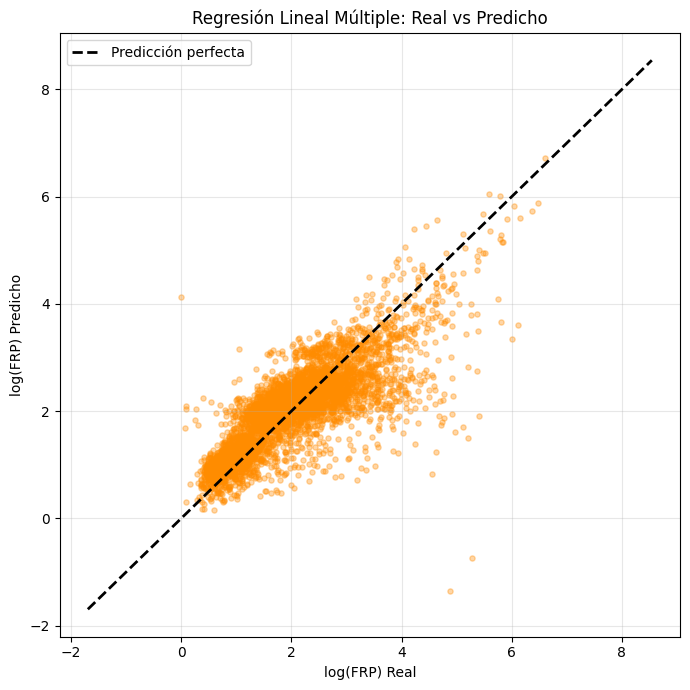

In [7]:
# Gráfico 1: Real vs Predicho (muestra)
muestra_idx_m = y_test_m.sample(5000, random_state=42).index
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_m.loc[muestra_idx_m], pd.Series(y_pred_m, index=y_test_m.index).loc[muestra_idx_m],
           color='darkorange', alpha=0.35, s=14)
lims = [min(y_test_m.min(), y_pred_m.min()), max(y_test_m.max(), y_pred_m.max())]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=2, label='Predicción perfecta')
ax.set_xlabel('log(FRP) Real')
ax.set_ylabel('log(FRP) Predicho')
ax.set_title('Regresión Lineal Múltiple: Real vs Predicho')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


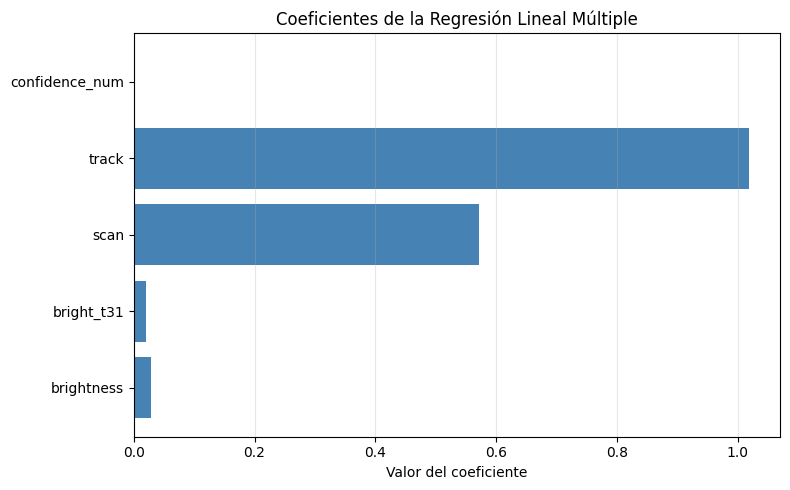

In [8]:
# Gráfico 2: Importancia relativa de cada variable (coeficientes)
plt.figure(figsize=(8, 5))
colores_coef = ['steelblue' if c > 0 else 'crimson' for c in modelo_multiple.coef_]
plt.barh(predictoras, modelo_multiple.coef_, color=colores_coef)
plt.xlabel('Valor del coeficiente')
plt.title('Coeficientes de la Regresión Lineal Múltiple')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


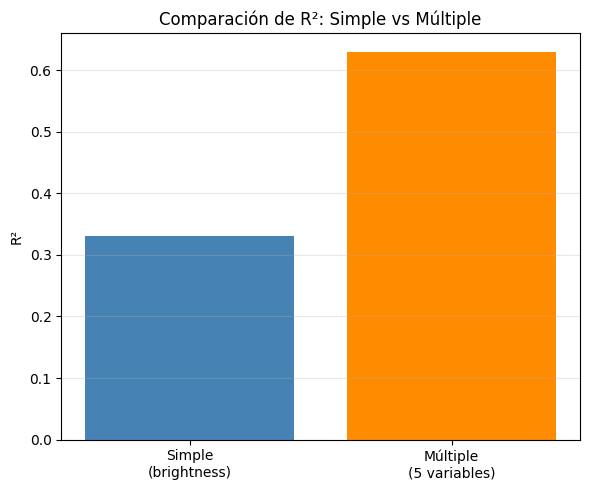

In [9]:
# Gráfico 3: Comparación Simple vs Múltiple (R2)
plt.figure(figsize=(6, 5))
plt.bar(['Simple\n(brightness)', 'Múltiple\n(5 variables)'],
        [r2_s, r2_m], color=['steelblue', 'darkorange'])
plt.ylabel('R²')
plt.title('Comparación de R²: Simple vs Múltiple')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 5. Regresión Logística

`daynight_num ~ brightness + bright_t31 + scan + track + frp`  (1 = Día, 0 = Noche)

In [10]:
predictoras_clas = ['brightness', 'bright_t31', 'scan', 'track', 'frp']
X = df[predictoras_clas]
y = df['daynight_num']  # 1 = Día, 0 = Noche

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train_s, y_train)

y_pred_log = modelo_log.predict(X_test_s)
y_prob_log = modelo_log.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred_log)
prec = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_prob_log)

print("REGRESIÓN LOGÍSTICA (daynight_num ~ brightness + bright_t31 + scan + track + frp)")
print("-" * 75)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print("\nReporte completo:\n", classification_report(y_test, y_pred_log, target_names=['Noche', 'Día']))


REGRESIÓN LOGÍSTICA (daynight_num ~ brightness + bright_t31 + scan + track + frp)
---------------------------------------------------------------------------
Accuracy : 0.8784
Precision: 0.8803
Recall   : 0.9183
F1-score : 0.8989
AUC      : 0.9274

Reporte completo:
               precision    recall  f1-score   support

       Noche       0.88      0.82      0.85     55290
         Día       0.88      0.92      0.90     79068

    accuracy                           0.88    134358
   macro avg       0.88      0.87      0.87    134358
weighted avg       0.88      0.88      0.88    134358



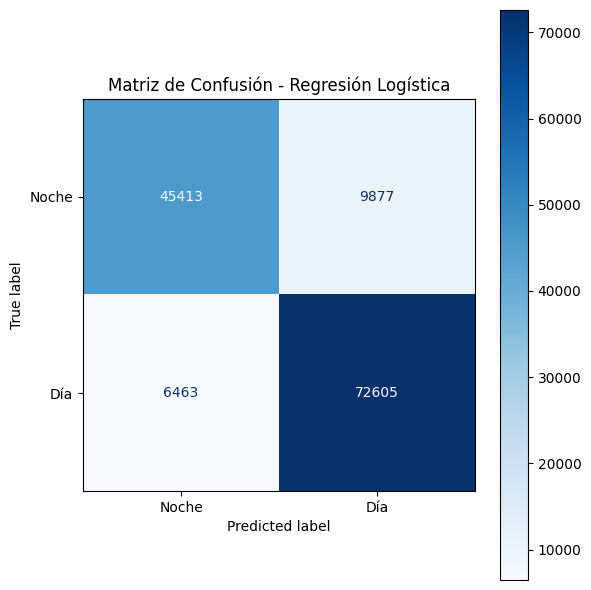

In [11]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, display_labels=['Noche', 'Día'], cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()


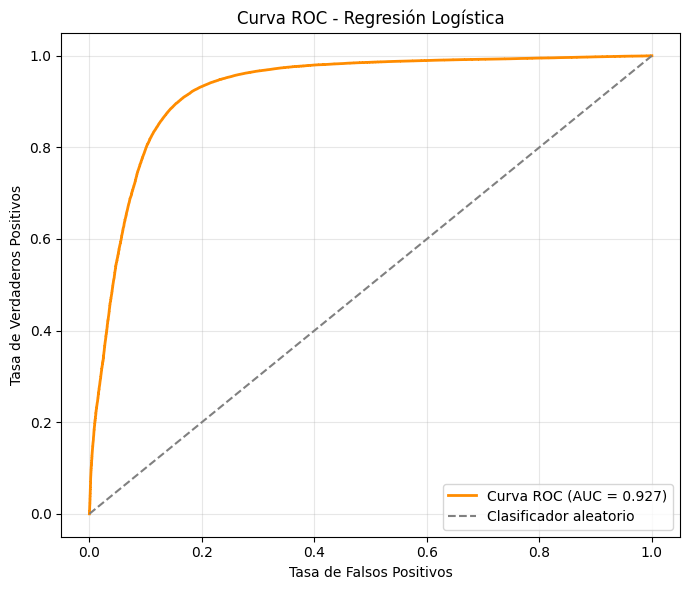

In [12]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'Curva ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


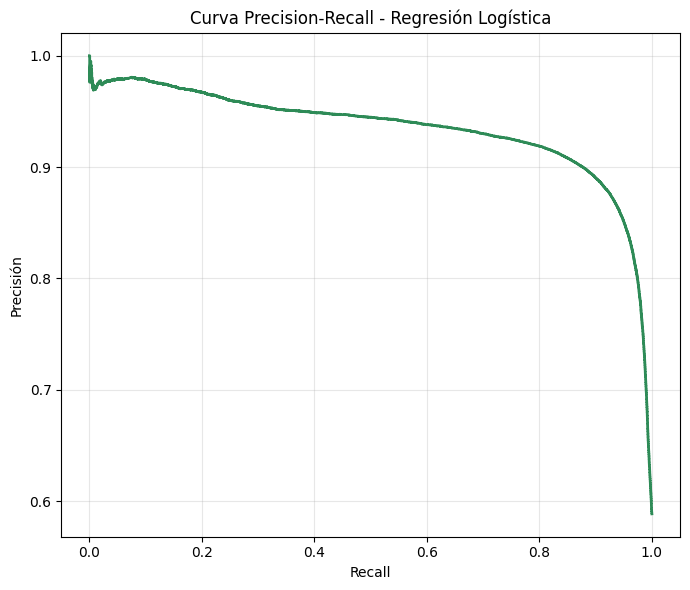

In [13]:
# Curva Precision-Recall
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_log)
plt.figure(figsize=(7, 6))
plt.plot(rec_curve, prec_curve, color='seagreen', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva Precision-Recall - Regresión Logística')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. KNN

`daynight_num ~ brightness + bright_t31 + scan + track + frp` — búsqueda del mejor *k* con `GridSearchCV`

In [14]:
predictoras_clas = ['brightness', 'bright_t31', 'scan', 'track', 'frp']

# Muestra balanceada (KNN es costoso con datasets muy grandes)
df_muestra = df.groupby('daynight_num', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 15000), random_state=42)
)

X = df_muestra[predictoras_clas]
y = df_muestra['daynight_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Búsqueda del mejor k con validación cruzada
param_grid = {'n_neighbors': np.arange(1, 21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_s, y_train)
best_k = grid.best_params_['n_neighbors']
print(f"Mejor valor de k encontrado: {best_k}")

# Modelo final
modelo_knn = KNeighborsClassifier(n_neighbors=best_k)
modelo_knn.fit(X_train_s, y_train)

y_pred_knn = modelo_knn.predict(X_test_s)
y_prob_knn = modelo_knn.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred_knn)
prec = precision_score(y_test, y_pred_knn)
rec = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
auc = roc_auc_score(y_test, y_prob_knn)

print("\nKNN (daynight_num ~ brightness + bright_t31 + scan + track + frp)")
print("-" * 75)
print(f"k óptimo : {best_k}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print("\nReporte completo:\n", classification_report(y_test, y_pred_knn, target_names=['Noche', 'Día']))


/tmp/ipykernel_2230/3432736096.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_muestra = df.groupby('daynight_num', group_keys=False).apply(


Mejor valor de k encontrado: 20

KNN (daynight_num ~ brightness + bright_t31 + scan + track + frp)
---------------------------------------------------------------------------
k óptimo : 20
Accuracy : 0.8882
Precision: 0.8882
Recall   : 0.8882
F1-score : 0.8882
AUC      : 0.9606

Reporte completo:
               precision    recall  f1-score   support

       Noche       0.89      0.89      0.89      4500
         Día       0.89      0.89      0.89      4500

    accuracy                           0.89      9000
   macro avg       0.89      0.89      0.89      9000
weighted avg       0.89      0.89      0.89      9000



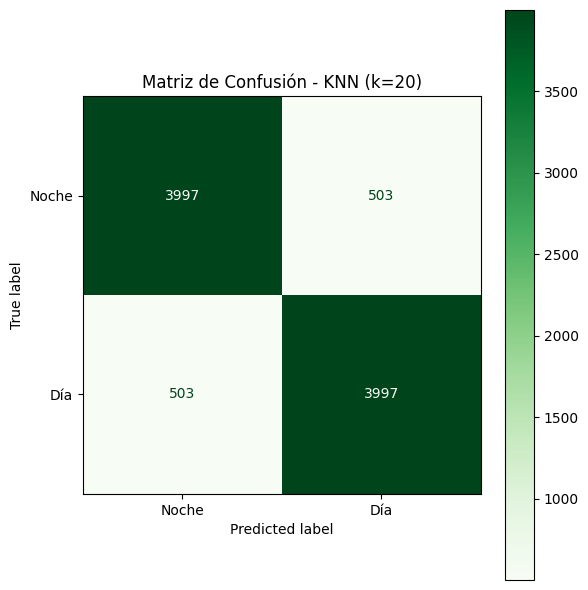

In [15]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn, display_labels=['Noche', 'Día'], cmap='Greens', ax=ax
)
ax.set_title(f'Matriz de Confusión - KNN (k={best_k})')
plt.tight_layout()
plt.show()


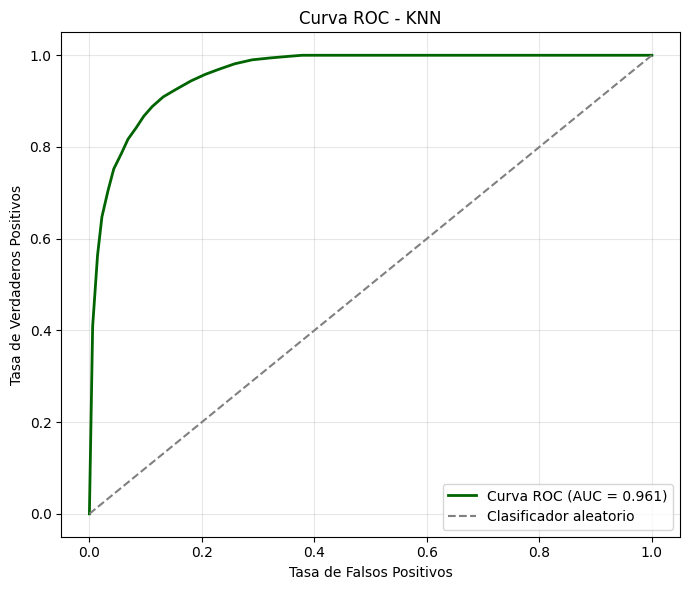

In [16]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkgreen', linewidth=2, label=f'Curva ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - KNN')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


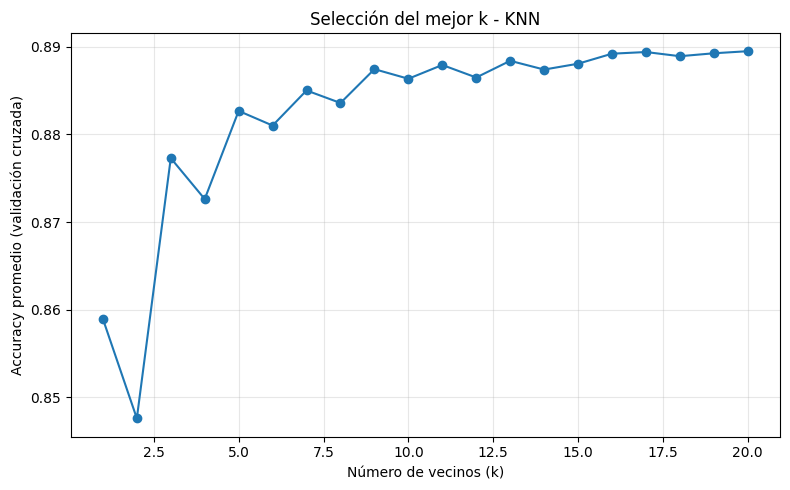

In [17]:
# Selección del mejor k (accuracy vs k)
resultados_k = grid.cv_results_['mean_test_score']
plt.figure(figsize=(8, 5))
plt.plot(param_grid['n_neighbors'], resultados_k, marker='o')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy promedio (validación cruzada)')
plt.title('Selección del mejor k - KNN')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
